In [13]:
#loading playstore dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from DataframeHandler import DataFrameHandler as dfh
import numpy as np
from matplotlib.ticker import FuncFormatter
df = dfh.read_csv_file("googleplaystore.csv")
dfh.describe_data(df)

,# Column,Column name,Non-Null Count,Missing,Dtype
0,#,Column,Non-Null,Count,Dtype
1,---,------,--------------,-----,
2,0,App,10841,non-null,object
3,1,Category,10841,non-null,object
4,2,Rating,9367,non-null,float64
5,3,Reviews,10841,non-null,object
6,4,Size,10841,non-null,object
7,5,Installs,10841,non-null,object
8,6,Type,10840,non-null,object
9,7,Price,10841,non-null,object



Number of rows and columns:
Number of rows: 10841
Number of columns: 13


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000



Sum of null values in each column:


,Null Counts
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [14]:
df['Rating'] = df['Rating'].fillna(-1)
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [15]:
df.describe()
df['Category'].unique()






array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
       '1.9'], dtype=object)

In [16]:


df = df[~df['Type'].isin(['0', np.nan])]

#dfh.encode_label_columns(df,['Type','Category'],['new_type','new_cat'])



KeyError: 'Cat'

In [17]:
df['Genres'].unique()



array(['Art & Design', 'Art & Design;Pretend Play',
       'Art & Design;Creativity', 'Art & Design;Action & Adventure',
       'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Comics;Creativity', 'Communication', 'Dating',
       'Education;Education', 'Education', 'Education;Creativity',
       'Education;Music & Video', 'Education;Action & Adventure',
       'Education;Pretend Play', 'Education;Brain Games', 'Entertainment',
       'Entertainment;Music & Video', 'Entertainment;Brain Games',
       'Entertainment;Creativity', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Lifestyle;Pretend Play',
       'Adventure;Action & Adventure', 'Arcade', 'Casual', 'Card',
       'Casual;Pretend Play', 'Action', 'Strategy', 'Puzzle', 'Sports',
       'Music', 'Word', 'Racing', 'Casual;Creativity',
       'Casual;Action & Adventure', 'Simulation', 'Adventure', 'Board',
       'Trivia', 'Role 

In [18]:
df['Genres'] = df['Genres'].str.split(';')  # Split into lists
genre_dummies = df['Genres'].str.join('|').str.get_dummies()
df = pd.concat([df, genre_dummies], axis=1)



In [19]:
print(df.dtypes['Installs'])


object


In [20]:
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].astype(int)
df['Installs']

0           10000
1          500000
2         5000000
3        50000000
4          100000
           ...   
10836        5000
10837         100
10838        1000
10839        1000
10840    10000000
Name: Installs, Length: 10839, dtype: int32

<AxesSubplot:>

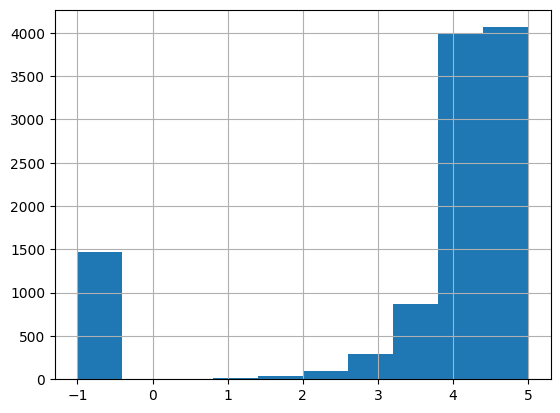

In [12]:
df['Rating'].hist()


In [12]:
top_10_apps = df.sort_values(by='Installs', ascending=False).head(10)
print(top_10_apps)

                                           App       Category  Rating  \
3665                                   YouTube  VIDEO_PLAYERS     4.3   
4104  Messenger – Text and Video Chat for Free  COMMUNICATION     4.0   
3896                            Subway Surfers           GAME     4.5   
3996              Google Chrome: Fast & Secure  COMMUNICATION     4.3   
3909                                 Instagram         SOCIAL     4.5   
865                          Google Play Games  ENTERTAINMENT     4.3   
464                                   Hangouts  COMMUNICATION     4.0   
1917                            Subway Surfers           GAME     4.5   
1700                            Subway Surfers           GAME     4.5   
3565                              Google Drive   PRODUCTIVITY     4.4   

       Reviews                Size    Installs  Type Price Content Rating  \
3665  25655305  Varies with device  1000000000  Free     0           Teen   
4104  56642847  Varies with device  100000

C:\Users\iasam\AppData\Local\Temp\ipykernel_11544\2818580993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Installs', y='App', data=top_10_apps, palette='viridis')


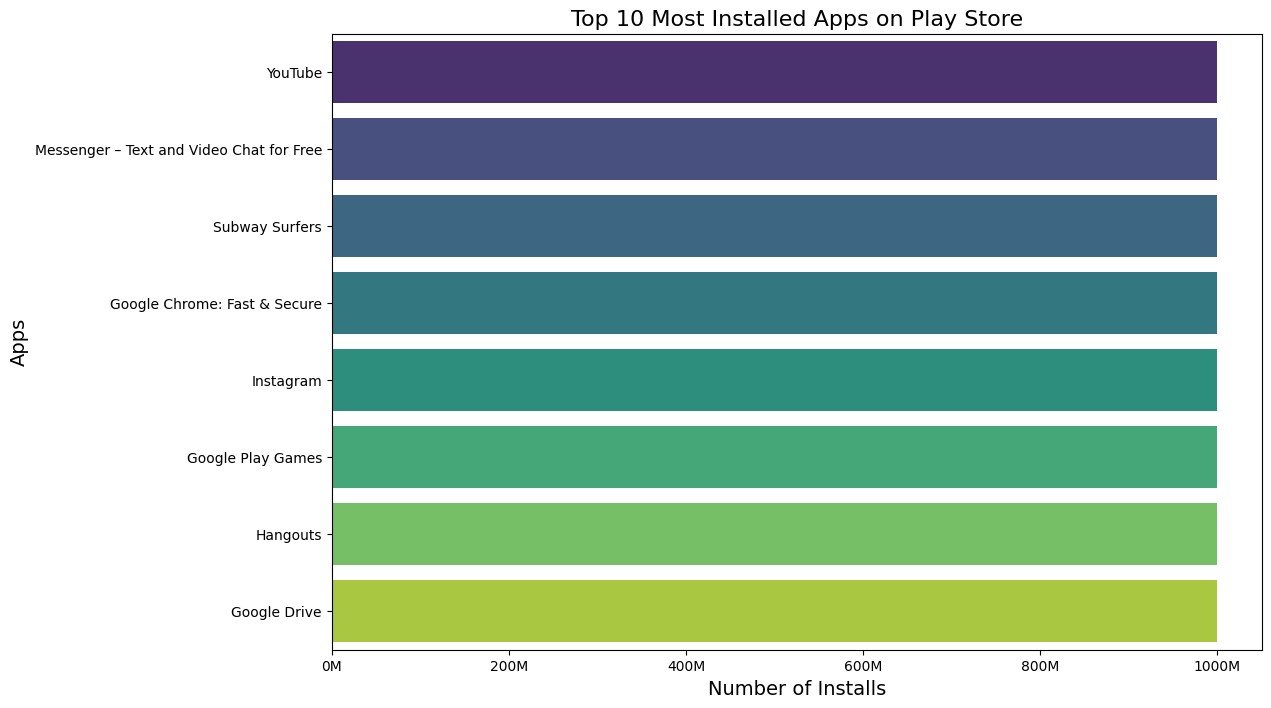

In [16]:
# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Installs', y='App', data=top_10_apps, palette='viridis')

# Add titles and labels
plt.title('Top 10 Most Installed Apps on Play Store', fontsize=16)
plt.xlabel('Number of Installs', fontsize=14)
plt.ylabel('Apps', fontsize=14)

formatter = FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
plt.gca().xaxis.set_major_formatter(formatter)
# Show the plot
plt.show()

C:\Users\iasam\AppData\Local\Temp\ipykernel_13216\4081510135.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Installs', y='App', data=top_10_unique_apps, palette='viridis')


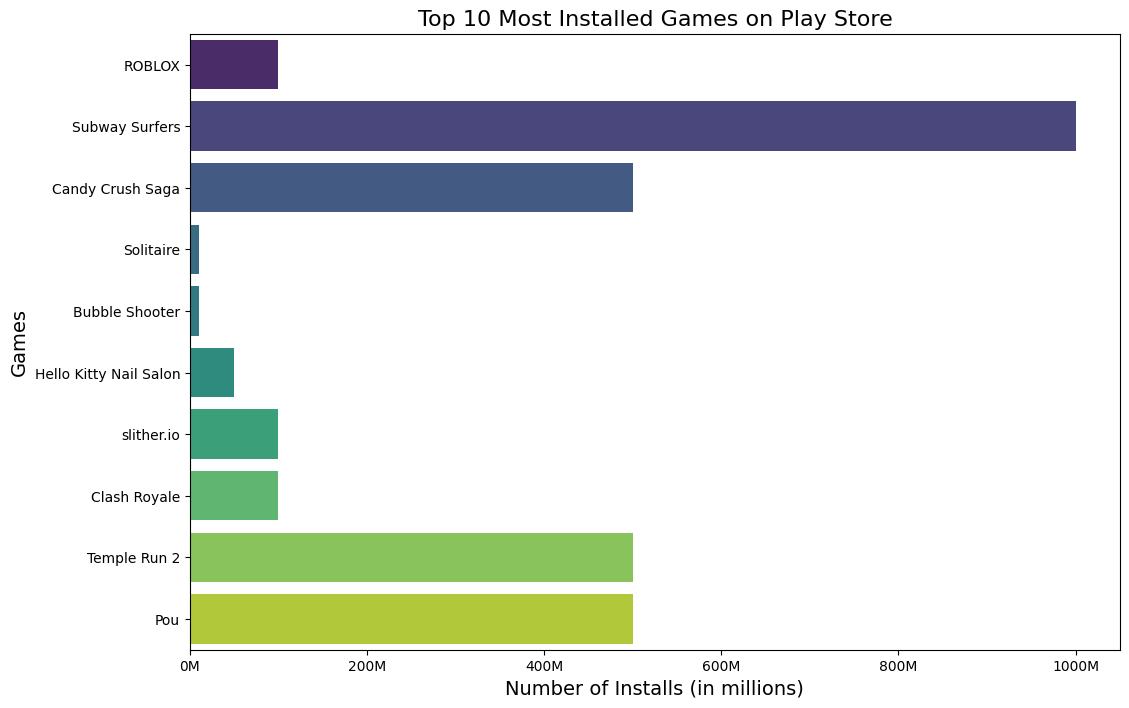

In [12]:
games_df = df[df['Category'] == 'GAME']

unique_apps = games_df.drop_duplicates(subset='App')

# Get the top 10 most installed unique apps
top_10_unique_apps = unique_apps.head(10)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Installs', y='App', data=top_10_unique_apps, palette='viridis')

# Add titles and labels
plt.title('Top 10 Most Installed Games on Play Store', fontsize=16)
plt.xlabel('Number of Installs (in millions)', fontsize=14)
plt.ylabel('Games', fontsize=14)

# Format x-axis ticks to show millions
formatter = FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
plt.gca().xaxis.set_major_formatter(formatter)

# Show the plot
plt.show()